In [2]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

In [3]:
final_model = joblib.load("../models/final_model.pkl")

In [4]:
df = pd.read_csv("../data/processed/feature_engineered.csv")

X = df.drop("Churn", axis=1)
y = df["Churn"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=y,
    random_state=42,
    test_size=0.2
)

In [17]:
print(X.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'TenureGroup', 'AvgMonthlySpend', 'IsNewCustomer', 'LongTermContract', 'TotalServices', 'SecurityBundle', 'StreamingUser', 'AutoPayment', 'PremiumCustomer']


In [6]:
y_pred = final_model.predict(X_test)

# Business Assumptions

In [7]:
retention_campaign_cost = 50
customer_lifetime_value = 500

# Confusion Matrix

In [8]:
tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred
).ravel()

print(tp, fp, fn, tn)

291 286 83 747


# Financial Impact

In [9]:
campaign_cost = (tp + fp) * retention_campaign_cost

In [10]:
revenue_saved = tp * customer_lifetime_value

In [11]:
net_benefit = revenue_saved - campaign_cost

In [12]:
roi = (
    net_benefit /
    campaign_cost
) * 100

# Results

In [13]:
business_results = pd.DataFrame({
    "Metric":[
        "True Positives",
        "False Positives",
        "Campaign Cost",
        "Revenue Saved",
        "Net Benefit",
        "ROI (%)"
    ],
    "Value":[
        tp,
        fp,
        campaign_cost,
        revenue_saved,
        net_benefit,
        roi
    ]
})

business_results

,Metric,Value
0,True Positives,291.000000
1,False Positives,286.000000
2,Campaign Cost,28850.000000
3,Revenue Saved,145500.000000
4,Net Benefit,116650.000000
5,ROI (%),404.332756


<BarContainer object of 2 artists>

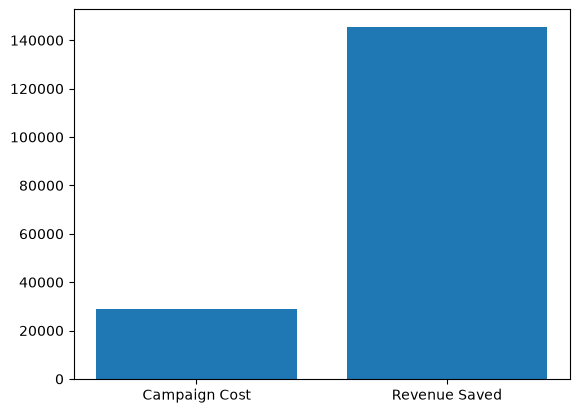

In [14]:
import matplotlib.pyplot as plt

plt.bar(
    ["Campaign Cost","Revenue Saved"],
    [campaign_cost,revenue_saved]
)

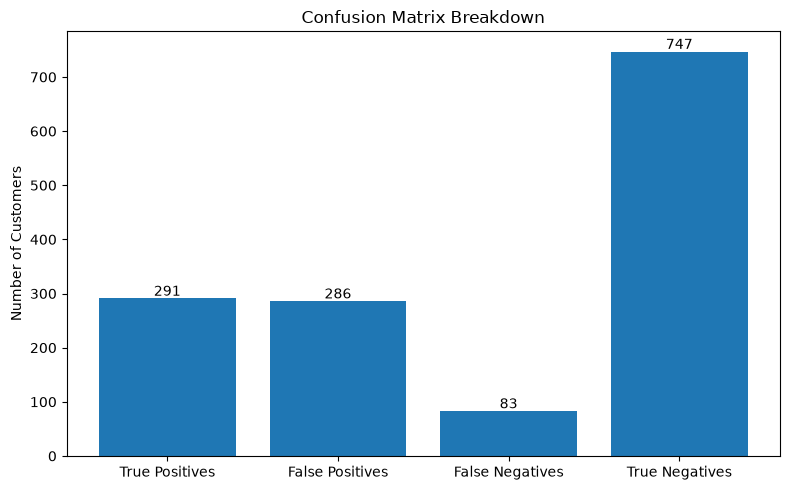

In [15]:
labels = ["True Positives", "False Positives", "False Negatives", "True Negatives"]
values = [tp, fp, fn, tn]

plt.figure(figsize=(8,5))

bars = plt.bar(labels, values)

plt.title("Confusion Matrix Breakdown")
plt.ylabel("Number of Customers")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 5,
        f"{int(height)}",
        ha="center"
    )

plt.tight_layout()
plt.show()

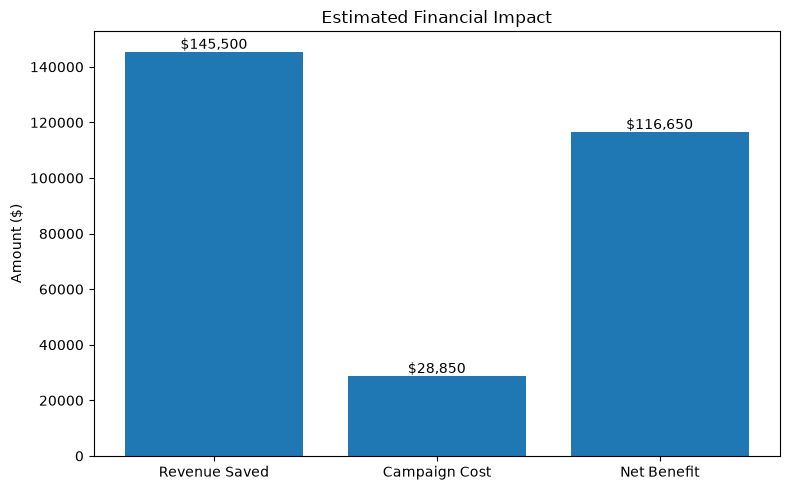

In [16]:
business_metrics = [
    "Revenue Saved",
    "Campaign Cost",
    "Net Benefit"
]

values = [
    revenue_saved,
    campaign_cost,
    net_benefit
]

plt.figure(figsize=(8,5))

bars = plt.bar(business_metrics, values)

plt.title("Estimated Financial Impact")
plt.ylabel("Amount ($)")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1000,
        f"${height:,.0f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

# Business Interpretation

The ROI analysis demonstrates that machine learning can improve customer retention not only by identifying customers at risk of churning but also by allocating marketing resources more efficiently.

While the model generates some False Positives, the relatively small cost of contacting these customers is outweighed by the potential revenue preserved from correctly identifying customers who would otherwise churn. This targeted approach is more efficient than applying retention campaigns indiscriminately across the entire customer base.

Overall, the results suggest that deploying the churn prediction model could support more informed decision-making and improve the cost-effectiveness of customer retention initiatives.

# Summary

Objective

Estimate the potential financial impact of deploying the customer churn prediction model using business-oriented metrics such as campaign cost, revenue preserved, net benefit, and return on investment.

Key Findings
The model correctly identified 291 customers who were at risk of churning.
Based on the assumed customer lifetime value and campaign cost, the model preserved an estimated $145,500 in future revenue while requiring an estimated $28,850 in retention campaign costs.
This resulted in an estimated net benefit of $116,650 and an ROI of 404.33%, indicating that the benefits substantially outweigh the costs under the stated assumptions.
Although some False Positives increased campaign expenditure, the overall financial impact remained strongly positive due to the successful identification of high-risk customers.
Conclusion

This business analysis demonstrates that the value of a machine learning model extends beyond predictive performance metrics. By translating predictions into estimated financial outcomes, organizations can evaluate whether deploying a churn prediction model is economically viable. Under the assumptions used in this study, the model has the potential to improve the efficiency of customer retention campaigns and generate a positive return on investment through targeted interventions.